In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("quora/question-pairs-dataset")

print("Path to dataset files:", path)

In [1]:

import pandas as pd
import copy
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
pd.read_csv("/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2/questions.csv")

In [ ]:
df=pd.read_csv("/root/.cache/kagglehub/datasets/quora/question-pairs-dataset/versions/2/questions.csv")
df.head()

In [47]:
df=pd.read_csv("questions.csv")

In [48]:
df1 = copy.deepcopy(df)

In [49]:
df1.columns

Index(['id', 'qid1', 'qid2', 'question1', 'question2', 'is_duplicate'], dtype='object')

In [51]:
df1

,id,qid1,qid2,question1,question2,is_duplicate
0,0,1,2,What is the step by step guide to invest in sh...,What is the step by step guide to invest in sh...,0
1,1,3,4,What is the story of Kohinoor (Koh-i-Noor) Dia...,What would happen if the Indian government sto...,0
2,2,5,6,How can I increase the speed of my internet co...,How can Internet speed be increased by hacking...,0
3,3,7,8,Why am I mentally very lonely? How can I solve...,Find the remainder when [math]23^{24}[/math] i...,0
4,4,9,10,"Which one dissolve in water quikly sugar, salt...",Which fish would survive in salt water?,0
...,...,...,...,...,...,...
404346,404346,789792,789793,How many keywords are there in the Racket prog...,How many keywords are there in PERL Programmin...,0
404347,404347,789794,789795,Do you believe there is life after death?,Is it true that there is life after death?,1
404348,404348,789796,789797,What is one coin?,What's this coin?,0
404349,404349,789798,789799,What is the approx annual cost of living while...,I am having little hairfall problem but I want...,0


In [52]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 404351 entries, 0 to 404350
Data columns (total 6 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            404351 non-null  int64 
 1   qid1          404351 non-null  int64 
 2   qid2          404351 non-null  int64 
 3   question1     404350 non-null  object
 4   question2     404349 non-null  object
 5   is_duplicate  404351 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 18.5+ MB


In [53]:
# missing values
df1.isnull().sum()

id              0
qid1            0
qid2            0
question1       1
question2       2
is_duplicate    0
dtype: int64

<Axes: >

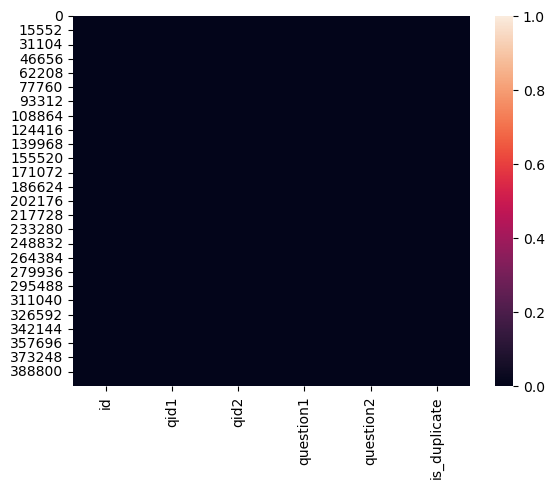

In [58]:
sns.heatmap(df1.isnull())

In [61]:
df1[df1['question1'].isnull()]
df1[df1['question2'].isnull()]

,id,qid1,qid2,question1,question2,is_duplicate
105796,105796,209841,209842,How can I develop android app?,NaN,0
201871,201871,398348,398349,How can I create an Android app?,NaN,0


<Axes: >

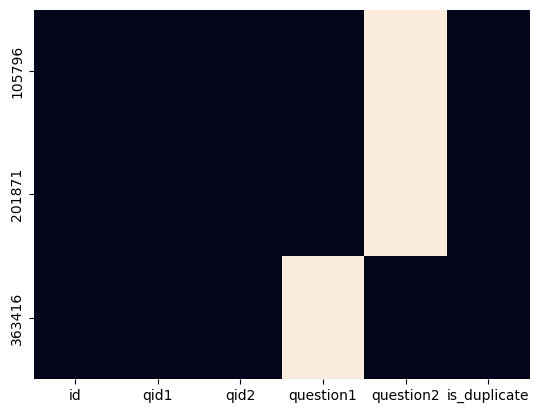

In [62]:
sns.heatmap(df1[df1.isnull().any(axis=1)].isnull(), cbar=False)

In [63]:
df1.dropna(inplace=True)

In [64]:
df1.isna().sum()

id              0
qid1            0
qid2            0
question1       0
question2       0
is_duplicate    0
dtype: int64

In [65]:
# duplicate rows
df1.duplicated().sum()

0

is_duplicate
0    255042
1    149306
Name: count, dtype: int64
is_duplicate
0    63.074876
1    36.925124
Name: count, dtype: float64


<Axes: xlabel='is_duplicate'>

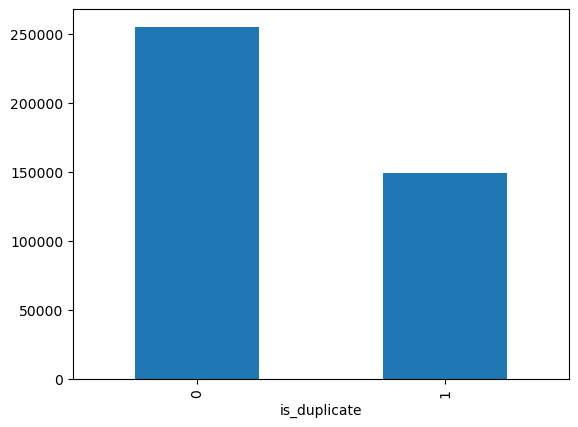

In [66]:
# Distribution of duplicate and non-duplicate questions

print(df1['is_duplicate'].value_counts())
print((df1['is_duplicate'].value_counts()/df1['is_duplicate'].count())*100)
df['is_duplicate'].value_counts().plot(kind='bar')

In [67]:
# Repeated questions

all_quest = pd.Series(df['qid1'].tolist() + df['qid2'].tolist())
print('Number of unique questions',np.unique(all_quest).shape[0])
x = all_quest.value_counts()>1
print('Number of questions getting repeated',x[x].shape[0])

Number of unique questions 789801
Number of questions getting repeated 13698


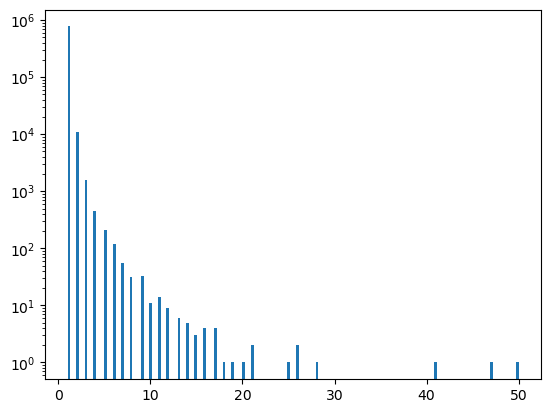

In [68]:
# Repeated questions histogram

plt.hist(all_quest.value_counts().values,bins=160)
plt.yscale('log')
plt.show()

# Using diff-vec way

In [82]:
new_df = df1.sample(30000)

In [84]:
ques_df =new_df[['question1','question2']]
ques_df.head()

,question1,question2
179031,"I am in Second year bcom and I need a job, can...",Had a 2nd great date that ended w a kiss and t...
37855,What is balanced chemical reaction for magnesi...,What is the chemical reaction of a salt water ...
252626,If there is one God then why there are so many...,"Religion: If you could ask God one question, w..."
37519,Does Troy University have a respected accredit...,How good is University of Technology Troyes Fr...
6695,When will Redmi Note 3 be available on Flipkar...,When will Xiaomi Redmi note 3 be available in ...


In [86]:
ques_df=ques_df.dropna()

# 1 Skip-Gram Word2Vec Model

### Step 1: Train a Skip-Gram Word2Vec Model

In [113]:
import gensim
from gensim.models import Word2Vec
import logging

# Enable logging
logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s",
    level=logging.INFO
)

# Combine questions
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Tokenize
sentences = [str(q).split() for q in questions]

# Train Skip-Gram Model
w2v_model = Word2Vec(
    sentences,
    vector_size=900,   # embedding dimension
    window=10,
    min_count=2,
    workers=4,
    epochs=10,
    sg=1     # sg=1 => Skip-Gram
)

2026-06-19 18:52:08,400 : INFO : collecting all words and their counts
2026-06-19 18:52:08,401 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-19 18:52:08,444 : INFO : PROGRESS: at sentence #10000, processed 109554 words, keeping 18135 word types
2026-06-19 18:52:08,492 : INFO : PROGRESS: at sentence #20000, processed 218646 words, keeping 28203 word types
2026-06-19 18:52:08,532 : INFO : PROGRESS: at sentence #30000, processed 327866 words, keeping 36351 word types
2026-06-19 18:52:08,574 : INFO : PROGRESS: at sentence #40000, processed 438385 words, keeping 41979 word types
2026-06-19 18:52:08,626 : INFO : PROGRESS: at sentence #50000, processed 549688 words, keeping 47170 word types
2026-06-19 18:52:08,666 : INFO : collected 51948 word types from a corpus of 661560 raw words and 60000 sentences
2026-06-19 18:52:08,667 : INFO : Creating a fresh vocabulary
2026-06-19 18:52:08,799 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retain

### Step 2: Convert Each Question to a Vector

In [116]:
def question_vector(question):
    
    words = str(question).split()

    vectors = []

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(900)

    return np.mean(vectors, axis=0)

### Step 3: Create Features for Question1

In [119]:
q1_vectors = np.array(
    ques_df['question1'].apply(question_vector).tolist()
)

q1_vectors.shape

(30000, 900)

### Step 4: Create Features for Question2

In [122]:
q2_vectors = np.array(
    ques_df['question2'].apply(question_vector).tolist()
)

q2_vectors.shape

(30000, 900)

### Step 5: Combine Both Questions

In [124]:
temp_df = pd.concat(
    [
        pd.DataFrame(q1_vectors),
        pd.DataFrame(q2_vectors)
    ],
    axis=1
)

temp_df.shape

(30000, 1800)

Why 600 Features Instead of 6000?

With BoW:

- 3000 + 3000 = 6000 features

With Word2Vec:

- 900 + 900 = 600 features

because each question is represented by a dense 300-dimensional embedding.

In [128]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,890,891,892,893,894,895,896,897,898,899
0,-0.038671,0.083826,-0.011865,0.095853,0.000181,0.017525,0.081902,0.046723,0.171468,0.036120,...,-0.025301,0.003505,0.065887,0.020875,0.086555,0.060852,0.010920,0.006394,0.131668,-0.007596
1,0.074227,0.123286,-0.020026,0.121369,-0.068930,0.009384,0.024989,0.159207,0.125545,0.045177,...,-0.032517,-0.039281,0.079792,-0.079667,0.047312,0.022177,-0.062705,0.015498,0.093303,0.003870
2,-0.066588,-0.028426,-0.021709,0.069661,0.008028,-0.053366,0.003115,0.172785,0.080279,-0.048162,...,0.056182,0.027441,0.122687,-0.080593,-0.054090,0.082044,0.044467,0.109288,0.117558,-0.016741
3,-0.037271,0.064106,0.029553,0.043790,-0.076880,-0.047601,0.169519,0.200502,0.170815,-0.051704,...,0.112631,-0.236196,0.027254,-0.116496,0.062222,-0.005405,-0.105962,0.021981,0.156489,0.056642
4,0.005303,0.008171,-0.078695,0.141418,-0.002180,-0.116421,0.026915,0.141559,0.140660,-0.003284,...,-0.030068,-0.004254,0.106492,-0.012954,0.008894,0.062477,-0.078241,0.052435,0.178680,0.019000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,0.016059,0.126771,-0.026925,0.133815,0.041130,0.059054,0.021685,0.226122,0.075867,-0.070954,...,-0.033915,0.005602,0.090646,0.023719,0.056721,-0.005335,-0.023811,-0.021844,0.131618,0.036568
29996,-0.052495,-0.007544,-0.042344,0.047017,-0.033000,-0.117774,0.114026,0.104349,0.103117,-0.111972,...,0.010092,-0.102290,0.021961,0.038662,0.093598,0.001991,-0.021781,-0.080640,0.189906,-0.007275
29997,-0.046937,-0.019975,0.019202,0.022258,0.013866,0.005113,0.095450,0.098877,0.044365,-0.020368,...,-0.104906,-0.089193,-0.119533,-0.183343,-0.048460,-0.056631,-0.114216,-0.071492,0.035429,0.083985
29998,-0.010614,0.061700,-0.069494,0.071170,-0.040763,0.039078,0.155950,0.116791,0.092196,-0.085889,...,-0.030125,-0.081854,0.088994,0.112988,0.025148,-0.023061,-0.061486,-0.017756,0.119664,0.001094


In [130]:
temp_df['is_duplicate'] = df1['is_duplicate']

In [132]:
temp_df.head()

,0,1,2,3,4,5,6,7,8,9,...,891,892,893,894,895,896,897,898,899,is_duplicate
0,-0.038671,0.083826,-0.011865,0.095853,0.000181,0.017525,0.081902,0.046723,0.171468,0.036120,...,0.003505,0.065887,0.020875,0.086555,0.060852,0.010920,0.006394,0.131668,-0.007596,0
1,0.074227,0.123286,-0.020026,0.121369,-0.068930,0.009384,0.024989,0.159207,0.125545,0.045177,...,-0.039281,0.079792,-0.079667,0.047312,0.022177,-0.062705,0.015498,0.093303,0.003870,0
2,-0.066588,-0.028426,-0.021709,0.069661,0.008028,-0.053366,0.003115,0.172785,0.080279,-0.048162,...,0.027441,0.122687,-0.080593,-0.054090,0.082044,0.044467,0.109288,0.117558,-0.016741,0
3,-0.037271,0.064106,0.029553,0.043790,-0.076880,-0.047601,0.169519,0.200502,0.170815,-0.051704,...,-0.236196,0.027254,-0.116496,0.062222,-0.005405,-0.105962,0.021981,0.156489,0.056642,0
4,0.005303,0.008171,-0.078695,0.141418,-0.002180,-0.116421,0.026915,0.141559,0.140660,-0.003284,...,-0.004254,0.106492,-0.012954,0.008894,0.062477,-0.078241,0.052435,0.178680,0.019000,0


In [134]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [135]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.609

In [ ]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

In [107]:
from xgboost import XGBClassifier

xgb = XGBClassifier(

    device="cuda",
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

C:\Users\p4pri\anaconda3\Lib\site-packages\xgboost\core.py:553: UserWarning: [18:48:29] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)


0.5785

# CBOW Word2Vec Model

### Step 1: Train a CBOW Word2Vec Model

In [88]:
import gensim
from gensim.models import Word2Vec
import logging

# Enable logging
logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s",
    level=logging.INFO
)

# Combine questions
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Tokenize
sentences = [str(q).split() for q in questions]

# Train Skip-Gram Model
w2v_model = Word2Vec(
    sentences,
    vector_size=900,   # embedding dimension
    window=10,
    min_count=2,
    workers=4,
    epochs=10
)

2026-06-20 16:30:57,078 : INFO : collecting all words and their counts
2026-06-20 16:30:57,082 : INFO : PROGRESS: at sentence #0, processed 0 words, keeping 0 word types
2026-06-20 16:30:57,109 : INFO : PROGRESS: at sentence #10000, processed 109416 words, keeping 18083 word types
2026-06-20 16:30:57,140 : INFO : PROGRESS: at sentence #20000, processed 219225 words, keeping 28127 word types
2026-06-20 16:30:57,165 : INFO : PROGRESS: at sentence #30000, processed 328928 words, keeping 36278 word types
2026-06-20 16:30:57,192 : INFO : PROGRESS: at sentence #40000, processed 440334 words, keeping 41949 word types
2026-06-20 16:30:57,223 : INFO : PROGRESS: at sentence #50000, processed 553312 words, keeping 47127 word types
2026-06-20 16:30:57,246 : INFO : collected 52033 word types from a corpus of 666320 raw words and 60000 sentences
2026-06-20 16:30:57,252 : INFO : Creating a fresh vocabulary
2026-06-20 16:30:57,335 : INFO : Word2Vec lifecycle event {'msg': 'effective_min_count=2 retain

### Step 2: Convert Each Question to a Vector

In [93]:
def question_vector(question):
    
    words = str(question).split()

    vectors = []

    for word in words:
        if word in w2v_model.wv:
            vectors.append(w2v_model.wv[word])

    if len(vectors) == 0:
        return np.zeros(900)

    return np.mean(vectors, axis=0)

### Step 3: Create Features for Question1

In [96]:
q1_vectors = np.array(
    ques_df['question1'].apply(question_vector).tolist()
)

q1_vectors.shape

(30000, 900)

### Step 4: Create Features for Question2

In [99]:
q2_vectors = np.array(
    ques_df['question2'].apply(question_vector).tolist()
)

q2_vectors.shape

(30000, 900)

### Step 5: Combine Both Questions

In [101]:
temp_df = pd.concat(
    [
        pd.DataFrame(q1_vectors),
        pd.DataFrame(q2_vectors)
    ],
    axis=1
)

temp_df.shape

(30000, 1800)

In [102]:
temp_df['is_duplicate'] = df1['is_duplicate']

In [103]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [104]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.6051666666666666

In [111]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.5838333333333333

# BOW

In [167]:
new_df = df1.sample(90000)

In [169]:
ques_df =new_df[['question1','question2']]
ques_df.head()

,question1,question2
107724,How should I proceed with my life?,How should I proceed in life?
150255,What are some underrated movies on IMDb?,What are some of the most underrated movies?
138574,How do I promote a new website?,How do I promote my new website?
155298,How can we earn money online without investment?,How can i make money online easily?
250744,Will India declare war against Pakistan?,Will India fight a war with Pakistan?


In [171]:
ques_df=ques_df.dropna()

In [173]:
# Import CountVectorizer to convert text into numerical feature vectors
from sklearn.feature_extraction.text import CountVectorizer

# Combine question1 and question2 into a single list
# This ensures the same vocabulary is learned from both columns
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Create a Bag-of-Words vectorizer
# Keep only the top 3000 most frequent words
cv = CountVectorizer(max_features=3000)

# Learn the vocabulary and transform all questions into vectors
# Shape after transformation:
# (number_of_questions * 2, 3000)
#
# np.vsplit(..., 2) splits the matrix into two equal parts:
# q1_arr -> vectors for question1
# q2_arr -> vectors for question2
q1_arr, q2_arr = np.vsplit(
    cv.fit_transform(questions).toarray(),
    2
)

# Convert question1 vectors into a DataFrame
temp_df1 = pd.DataFrame(q1_arr, index=ques_df.index)

# Convert question2 vectors into a DataFrame
temp_df2 = pd.DataFrame(q2_arr, index=ques_df.index)

# Concatenate both question representations side-by-side
# Final shape becomes:
# (30000, 6000)
# 3000 features from question1 + 3000 features from question2 = 6000
# 30000 Row data  
temp_df = pd.concat([temp_df1, temp_df2], axis=1)

# Display shape of the final feature matrix
temp_df.shape

(90000, 6000)

In [174]:
temp_df

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
107724,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
150255,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
138574,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
155298,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
250744,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
52594,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
42157,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
214627,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
353694,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [175]:
temp_df['is_duplicate'] = df1['is_duplicate']

In [176]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(temp_df.iloc[:,0:-1].values,temp_df.iloc[:,-1].values,test_size=0.2,random_state=1)

In [177]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
rf = RandomForestClassifier()
rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)
accuracy_score(y_test,y_pred)

0.7731666666666667

In [178]:
from xgboost import XGBClassifier
xgb = XGBClassifier()
xgb.fit(X_train,y_train)
y_pred = xgb.predict(X_test)
accuracy_score(y_test,y_pred)

0.7338888888888889

-----

----

# TfidfVectorizer

In [156]:
new_df = df1.sample(90000)

In [158]:
# Drop missing values
ques_df =new_df[['question1','question2']]
ques_df=ques_df.dropna()

In [161]:
 from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from scipy.sparse import hstack


# Enable logging
logging.basicConfig(
    format="%(asctime)s : %(levelname)s : %(message)s",
    level=logging.INFO
)


# Learn vocabulary from both question columns
questions = list(ques_df['question1']) + list(ques_df['question2'])

# Create TF-IDF vectorizer
tfidf = TfidfVectorizer(
    max_features=3000,
    stop_words='english'
)

# Fit on all questions
tfidf.fit(questions)

# Transform each question column
q1_arr = tfidf.transform(ques_df['question1'])
q2_arr = tfidf.transform(ques_df['question2'])

# Combine question1 and question2 features
X = hstack((q1_arr, q2_arr))

# Target variable
y = new_df['is_duplicate']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Shape of X:", X.shape)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)

Shape of X: (90000, 6000)
Shape of X_train: (72000, 6000)
Shape of X_test: (18000, 6000)


In [162]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7543888888888889


In [163]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

xgb.fit(X_train, y_train)

y_pred = xgb.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7145555555555556


-----

---

# Final Conclusion

The study demonstrates that for the Quora Question Pair dataset, Bag-of-Words and engineered textual similarity features outperform Word2Vec embeddings. The highest accuracy of 75.44% was achieved using a Random Forest classifier, making it the most suitable model among the approaches tested. Therefore, it can be concluded that Word2Vec embeddings alone are not sufficient for this task, and traditional feature engineering remains highly effective for duplicate question detection.